In [1]:
import numpy as np
import os

# Look for the file
for root, dirs, files in os.walk('/workspace'):
 for f in files:
 if 'DH_family' in f or 'DH_family_results' in f:
 print(os.path.join(root, f))


In [2]:
import subprocess
result = subprocess.run(['find', '/workspace', '-name', '*.npy', '-o', '-name', '*.npz'], capture_output=True, text=True)
print(result.stdout)


/workspace/600f7b9e-5f09-4cca-8f5e-ff607f541a45/betas.npy
/workspace/600f7b9e-5f09-4cca-8f5e-ff607f541a45/M_F1.npy
/workspace/600f7b9e-5f09-4cca-8f5e-ff607f541a45/lambda_min.npy
/workspace/600f7b9e-5f09-4cca-8f5e-ff607f541a45/target_betas.npy
/workspace/600f7b9e-5f09-4cca-8f5e-ff607f541a45/M_betas.npy
/workspace/600f7b9e-5f09-4cca-8f5e-ff607f541a45/t_peaks.npy
/workspace/600f7b9e-5f09-4cca-8f5e-ff607f541a45/trace.npy
/workspace/600f7b9e-5f09-4cca-8f5e-ff607f541a45/Fro_norm.npy
/workspace/600f7b9e-5f09-4cca-8f5e-ff607f541a45/Sk_peaks.npy
/workspace/600f7b9e-5f09-4cca-8f5e-ff607f541a45/Frobenius.npy
/workspace/600f7b9e-5f09-4cca-8f5e-ff607f541a45/lambda1_max.npy
/workspace/600f7b9e-5f09-4cca-8f5e-ff607f541a45/lam1_norm.npy
/workspace/600f7b9e-5f09-4cca-8f5e-ff607f541a45/kappas.npy



In [3]:
import numpy as np
import os

os.chdir('/workspace/600f7b9e-5f09-4cca-8f5e-ff607f541a45')

files = ['betas','kappas','target_betas','Fro_norm','Frobenius','lam1_norm',
 'lambda1_max','lambda_min','trace']
arrs = {f: np.load(f'{f}.npy') for f in files}
for k,v in arrs.items():
 print(f'{k}: shape={v.shape}, dtype={v.dtype}')
 print(f' values: {v}')


betas: shape=(7,), dtype=float64
 values: [0.55 0.6 0.65 0.7 0.75 0.8 0.85]
kappas: shape=(7,), dtype=float64
 values: [-1.0941777 -0.48934861 -0.18471125 0.01073438 0.15292442 0.26653593
 0.36447339]
target_betas: shape=(7,), dtype=float64
 values: [0.55 0.6 0.65 0.7 0.75 0.8 0.85]
Fro_norm: shape=(7,), dtype=float64
 values: [0.61044485 0.64571568 0.68301402 0.69366432 0.68130051 0.66591938
 0.65189117]
Frobenius: shape=(7,), dtype=float64
 values: [26.30086593 29.59773444 30.86830335 31.11233128 30.89735219 30.54386869
 30.12487421]
lam1_norm: shape=(7,), dtype=float64
 values: [0.29611236 0.36274313 0.41745661 0.4298675 0.41828108 0.40162368
 0.38417621]
lambda1_max: shape=(7,), dtype=float64
 values: [12.7280911 7.60775966 6.49896007 6.32532887 6.26009784 6.34638171
 6.55417094]
lambda_min: shape=(7,), dtype=float64
 values: [-21.43700951 -28.31659186 -29.98031104 -30.27404911 -30.0620617
 -29.66907859 -29.17287926]
trace: shape=(7,), dtype=float64
 values: [ -0.09024337 -19.92483

In [4]:
from scipy import stats
import pandas as pd

beta = arrs['betas']
kappa = arrs['kappas']
abs_kappa = np.abs(kappa)

print("Data summary:")
print(f"beta = {beta}")
print(f"kappa = {kappa}")
print(f"|kappa| = {abs_kappa}")
print(f"n = {len(beta)}")

# Candidate Y statistics
candidates = {
 'lambda1_max': arrs['lambda1_max'],
 'lambda_min': arrs['lambda_min'],
 'lam1_norm': arrs['lam1_norm'],
 'Frobenius': arrs['Frobenius'],
 'Fro_norm': arrs['Fro_norm'],
 'trace': arrs['trace'],
}

results = []
for name, Y in candidates.items():
 # Original (uncorrected) correlation Y vs beta
 r0_p, p0_p = stats.pearsonr(Y, beta)
 r0_s, p0_s = stats.spearmanr(Y, beta)

 # Linear regression Y ~ |kappa|
 slope, intercept, r_kappa, p_kappa, se = stats.linregress(abs_kappa, Y)
 Y_pred = slope * abs_kappa + intercept
 Y_resid = Y - Y_pred

 # Correlate residuals with beta
 r_p, p_p = stats.pearsonr(Y_resid, beta)
 r_s, p_s = stats.spearmanr(Y_resid, beta)

 results.append({
 'statistic': name,
 'orig_pearson_r': r0_p, 'orig_pearson_p': p0_p,
 'orig_spearman_r': r0_s, 'orig_spearman_p': p0_s,
 'kappa_R2': r_kappa**2,
 'resid_pearson_r': r_p, 'resid_pearson_p': p_p,
 'resid_spearman_r': r_s, 'resid_spearman_p': p_s,
 })

df = pd.DataFrame(results)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pd.set_option('display.width', 200)
print(df.to_string(index=False))


Data summary:
beta = [0.55 0.6 0.65 0.7 0.75 0.8 0.85]
kappa = [-1.0941777 -0.48934861 -0.18471125 0.01073438 0.15292442 0.26653593
 0.36447339]
|kappa| = [1.0941777 0.48934861 0.18471125 0.01073438 0.15292442 0.26653593
 0.36447339]
n = 7
 statistic orig_pearson_r orig_pearson_p orig_spearman_r orig_spearman_p kappa_R2 resid_pearson_r resid_pearson_p resid_spearman_r resid_spearman_p
lambda1_max -0.6951 0.0830 -0.5357 0.2152 0.9054 -0.4714 0.2856 -0.5000 0.2532
 lambda_min -0.6370 0.1239 -0.3929 0.3833 0.9392 -0.3113 0.4967 -0.2500 0.5887
 lam1_norm 0.5722 0.1794 0.3929 0.3833 0.9872 -0.0189 0.9679 -0.1429 0.7599
 Frobenius 0.6155 0.1412 0.3929 0.3833 0.9760 0.2868 0.5329 0.2500 0.5887
 Fro_norm 0.4421 0.3206 0.3214 0.4821 0.9463 -0.5191 0.2325 -0.5714 0.1802
 trace -0.6655 0.1027 -0.3929 0.3833 0.9268 -0.4028 0.3703 -0.4286 0.3374


In [5]:
# Diagnostic: check non-monotonicity of statistics with beta - the data looks like an inverted U pattern
# Note that beta and |kappa| are highly anti-correlated (since kappa monotonically increases with beta)
r_beta_kappa, p_bk = stats.pearsonr(beta, abs_kappa)
print(f"Correlation beta vs |kappa|: r = {r_beta_kappa:.4f}, p = {p_bk:.4g}")
r_beta_kappa_s, p_bk_s = stats.spearmanr(beta, abs_kappa)
print(f"Spearman beta vs |kappa|: r = {r_beta_kappa_s:.4f}, p = {p_bk_s:.4g}")

# This is the multicollinearity issue - regressing on |kappa| alone removes most signal
print("\nThe signal in beta and |kappa| are highly redundant.")


Correlation beta vs |kappa|: r = -0.5781, p = 0.174
Spearman beta vs |kappa|: r = -0.3929, p = 0.3833

The signal in beta and |kappa| are highly redundant.


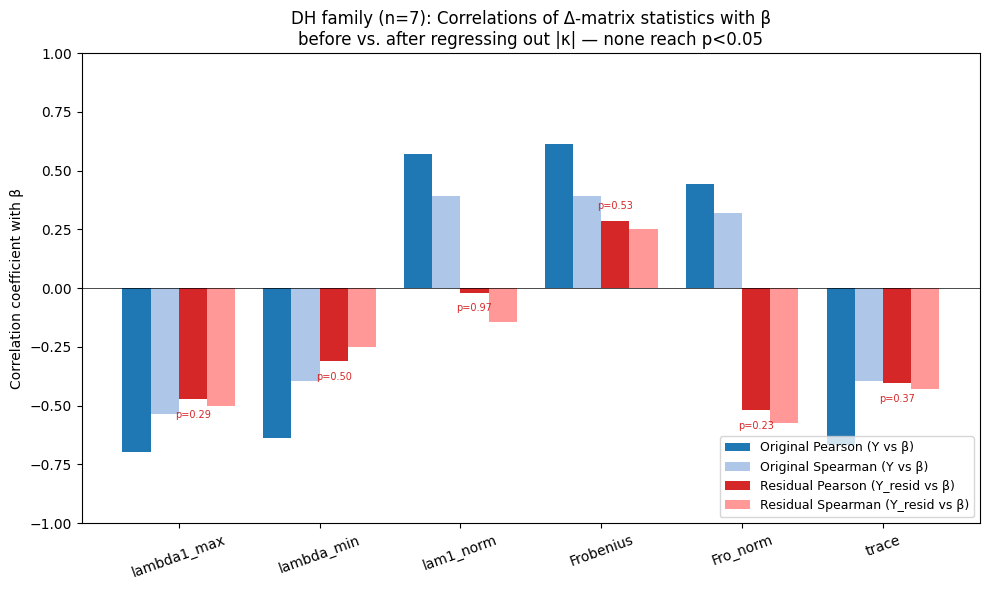

Saved figure


In [6]:
# Save results table
df.to_csv('residual_correlation_results.csv', index=False)

# Final summary figure: comparison of original vs residual correlations
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

stats_names = df['statistic'].values
x = np.arange(len(stats_names))
width = 0.2

ax.bar(x - 1.5*width, df['orig_pearson_r'], width, label='Original Pearson (Y vs β)', color='#1f77b4')
ax.bar(x - 0.5*width, df['orig_spearman_r'], width, label='Original Spearman (Y vs β)', color='#aec7e8')
ax.bar(x + 0.5*width, df['resid_pearson_r'], width, label='Residual Pearson (Y_resid vs β)', color='#d62728')
ax.bar(x + 1.5*width, df['resid_spearman_r'], width, label='Residual Spearman (Y_resid vs β)', color='#ff9896')

ax.axhline(0, color='black', lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(stats_names, rotation=20)
ax.set_ylabel('Correlation coefficient with β')
ax.set_title('DH family (n=7): Correlations of Δ-matrix statistics with β\n'
 'before vs. after regressing out |κ| — none reach p<0.05')
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(-1, 1)

# Annotate the strongest residual p-values
for i, (rp, pp) in enumerate(zip(df['resid_pearson_r'], df['resid_pearson_p'])):
 ax.text(i + 0.5*width, rp + (0.05 if rp >= 0 else -0.08),
 f'p={pp:.2f}', ha='center', fontsize=7, color='#d62728')

plt.tight_layout()
plt.savefig('residual_correlation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure")
